<a href="https://colab.research.google.com/github/KrishDalvi/Pandas/blob/main/Session_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
# Question 1

print("--- Q1: Loading Dataset ---")
# Replace 'heart_disease_mock_data.csv' with your file path if needed
df = pd.read_csv('heart.csv')

print("\nFirst 10 rows of the dataset:")
print(df.head(10))
print("=" * 50)

print(f"\nShape of the dataset: {df.shape}")
print("=" * 50)

print("\nBasic Information (info()):")
df.info()
print("=" * 50)

--- Q1: Loading Dataset ---

First 10 rows of the dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease 

In [ ]:
# Question 2

print("\n--- Q2: Missing Values Check ---")
null_counts = df.isnull().sum()
print("Count of null values for each column:")
print(null_counts)
print("=" * 50)


--- Q2: Missing Values Check ---
Count of null values for each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Question 3

print("\n--- Q3: Duplicate Rows Check ---")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully.")
    print(f"New shape of the dataset: {df.shape}")
else:
    print("No duplicates found to remove.")
print("=" * 50)


--- Q3: Duplicate Rows Check ---
Number of duplicate rows found: 0
No duplicates found to remove.


In [ ]:
# Question 4

print("\n--- Q4: Identify Unrealistic Values ---")
chol_zero_count = (df["Cholesterol"] == 0).sum()
bp_zero_count = (df["RestingBP"] == 0).sum()

print(f"Rows with Cholesterol = 0: {chol_zero_count}")
print(f"Rows with RestingBP = 0: {bp_zero_count}")
print("=" * 50)


--- Q4: Identify Unrealistic Values ---
Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


In [ ]:
# Question 5

print("\n--- Q5: Cleaning Invalid Values ---")
print("\nStatistical Summary Befor Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

# Calculate means excluding 0
mean_chol = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
mean_bp = df[df["RestingBP"] != 0]["RestingBP"].mean()

# Replace 0 with mean and round to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].replace(0, mean_chol).round(2)
df["RestingBP"] = df["RestingBP"].replace(0, mean_bp).round(2)
print("=" * 50)

print("\nStatistical Summary After Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())
print("=" * 50)


--- Q5: Cleaning Invalid Values ---

Statistical Summary Befor Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

Statistical Summary After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


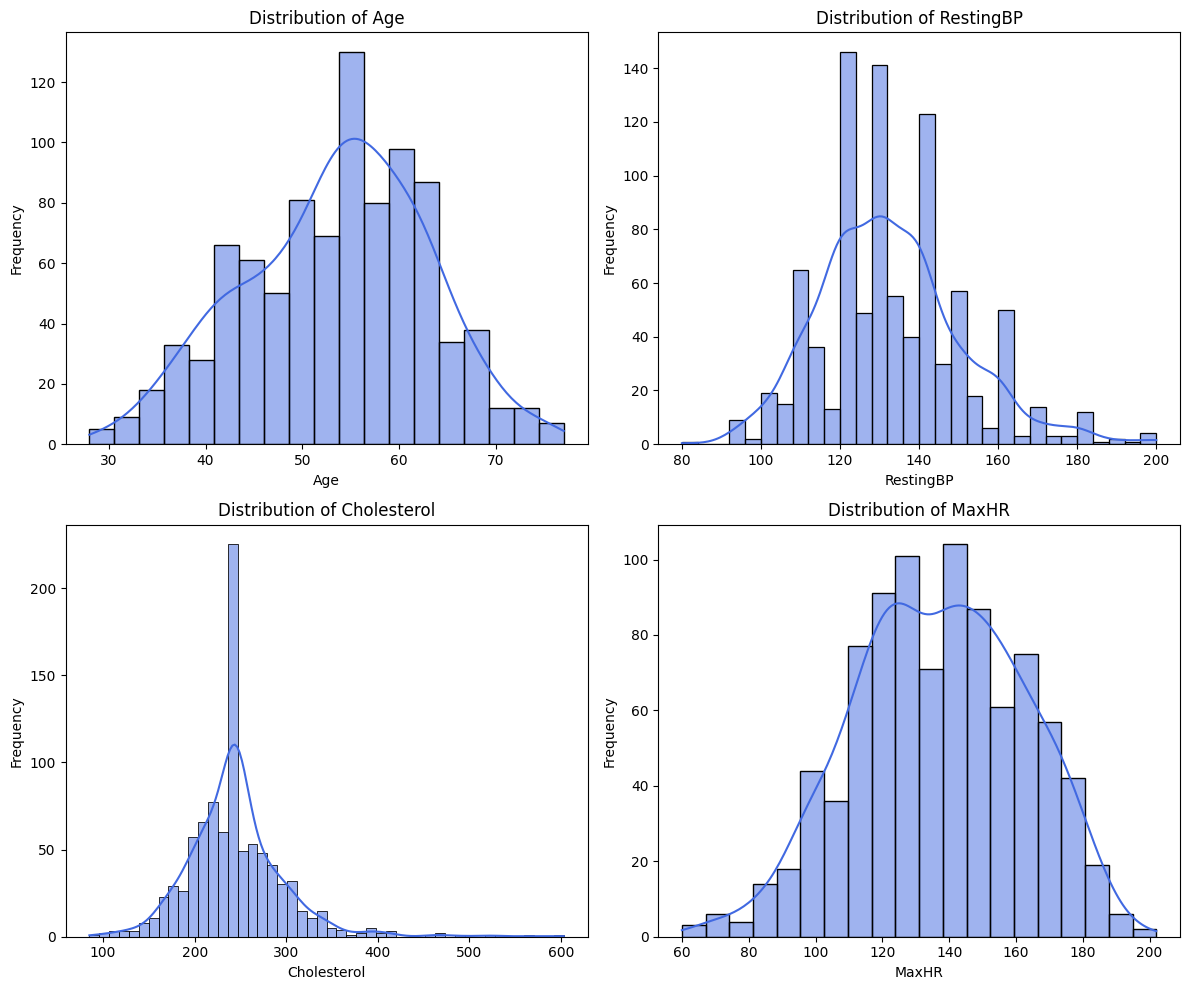

In [ ]:
# Question 6

def plot_histograms(dataframe):
    numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    # Set up a 2x2 subplot layout
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    axes = axes.flatten()  # Flatten into a 1D array for easier looping

    for index, col in enumerate(numerical_cols):
        sns.histplot(
            dataframe[col],
            ax=axes[index],
            kde=True,
            color="royalblue",
            edgecolor="black"
        )
        axes[index].set_title(f"Distribution of {col}")
        axes[index].set_xlabel(col)
        axes[index].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


plot_histograms(df)

In [ ]:
# Questiom 7
print("\n--- Q7: Identify Column Types ---")
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"\nNumerical Columns: {numerical_columns}")
print(f"\nCategorical Columns: {categorical_columns}")
print("-" * 96)



--- Q7: Identify Column Types ---

Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
------------------------------------------------------------------------------------------------


In [ ]:
#Question 8

print("\n--- Q8: One-Hot Encoding ---")
# Perform One-Hot Encoding on identified categorical features
df_encoded = pd.get_dummies(df, columns=categorical_columns)

print(f"Shape of df_encoded: {df_encoded.shape}")
print("\nFirst 5 rows of df_encoded:")
print(df_encoded.head())
print("=" * 95)


--- Q8: One-Hot Encoding ---
Shape of df_encoded: (918, 21)

First 5 rows of df_encoded:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True 

In [ ]:
# Question 9

print("\n--- Q9: Final Structural Check ---")
print(f"Final shape of df_encoded: {df_encoded.shape}")
print("\nList of all column names in the final dataframe:")
print(df_encoded.columns.tolist())
print("=" * 350)


--- Q9: Final Structural Check ---
Final shape of df_encoded: (918, 21)

List of all column names in the final dataframe:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [ ]:
# Question 10
print("=============================================")
print("                Q10: SUMMARY                 ")
print("=============================================\n")

print("1. INVALID VALUES & FIXES:")
print("- Found biologically impossible values: Cholesterol = 0 and RestingBP = 0.")
print("- Fixed by replacing the 0s with the mean of their respective columns (excluding zeros).\n")

print("2. IMPORTANCE OF HANDLING INVALID VALUES:")
print("- Leaving 0s in skews the statistical distribution and lowers the mean.")
print("- It confuses the ML model and leads to highly inaccurate predictions.\n")

print("3. PURPOSE OF ONE-HOT ENCODING:")
print("- ML models only understand numbers, not text/categories.")
print("- It converts text categories into binary (1s and 0s) without assigning a false mathematical ranking/order.\n")

print("4. OTHER OBSERVATIONS:")
print("- The dataset had no standard 'NaN' missing values.")
print("- It proves that data cleaning requires checking for unrealistic values, not just nulls.")
print("=" * 95)

                Q10: SUMMARY                 

1. INVALID VALUES & FIXES:
- Found biologically impossible values: Cholesterol = 0 and RestingBP = 0.
- Fixed by replacing the 0s with the mean of their respective columns (excluding zeros).

2. IMPORTANCE OF HANDLING INVALID VALUES:
- Leaving 0s in skews the statistical distribution and lowers the mean.
- It confuses the ML model and leads to highly inaccurate predictions.

3. PURPOSE OF ONE-HOT ENCODING:
- ML models only understand numbers, not text/categories.
- It converts text categories into binary (1s and 0s) without assigning a false mathematical ranking/order.

4. OTHER OBSERVATIONS:
- The dataset had no standard 'NaN' missing values.
- It proves that data cleaning requires checking for unrealistic values, not just nulls.
